<a href="https://colab.research.google.com/github/SalvaPiol45Tech/Multimodel-/blob/main/copy_of_medical_xray_report_generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Medical X-Ray Report Generator

A Vision-Language Model that reads chest X-Ray images and generates medical reports.

**Architecture:**
- 🔒 **Frozen CLIP** Vision Encoder → extracts visual features
- 🔗 **MLP Projection** → maps visual features to text space
- 📝 **GPT-style Decoder** → generates report token by token

**Dataset:** IU X-Ray (Indiana University) — 7,470 chest X-Rays with radiology reports

## 1. Install & Import

In [ ]:
# Install required libraries
!pip install transformers datasets torch torchvision --quiet

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPProcessor, CLIPModel, AutoTokenizer
import pandas as pd
import numpy as np
from PIL import Image
import requests
import os
import json
import zipfile
import matplotlib.pyplot as plt
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Download IU X-Ray Dataset

In [ ]:
# ─────────────────────────────────────────────────────────
# Use a smaller, paired dataset: OpenI (IU X-Ray) via CSV
# This dataset has actual radiology reports paired with images
# ─────────────────────────────────────────────────────────

# Download the reports CSV from GitHub mirror
!wget -q https://raw.githubusercontent.com/chuangg/find_mip/master/data/iuxray/reports.json -O reports.json

# Download images
!wget -q https://openi.nlm.nih.gov/imgs/collections/NLMCXR_png.tgz -O xray_images.tgz
!tar -xzf xray_images.tgz -C /content/ 2>/dev/null || echo 'Images extracted (or already exist)'

print('Download complete!')

^C
Images extracted (or already exist)
Download complete!


In [ ]:
# ─────────────────────────────────────────────────────────
# FALLBACK: If download fails, we create synthetic data
# for architecture testing (replace with real data later)
# ─────────────────────────────────────────────────────────

def create_synthetic_dataset(n_samples=200):
    """Creates synthetic paired (image, report) data for testing the pipeline."""
    templates = [
        "The lungs are clear. No evidence of pneumonia or pleural effusion. Heart size is normal.",
        "Mild cardiomegaly is noted. The lungs show no acute airspace disease. No pleural effusion.",
        "There is increased opacity in the right lower lobe, suggesting possible pneumonia. Heart size normal.",
        "The lungs are hyperinflated, consistent with COPD. No acute infiltrates. Heart size normal.",
        "No acute cardiopulmonary findings. The cardiac silhouette is within normal limits.",
        "Bilateral interstitial opacities are present. Clinical correlation suggested for possible edema.",
        "The trachea is midline. No pneumothorax or pleural effusion. Bones appear intact.",
        "There is blunting of the left costophrenic angle, suggesting a small pleural effusion.",
    ]
    data = []
    for i in range(n_samples):
        # Synthetic grayscale X-ray (random noise as placeholder)
        img_array = np.random.randint(30, 200, (224, 224), dtype=np.uint8)
        # Add some structure to make it vaguely X-ray-like
        img_array[80:160, 60:160] = np.random.randint(150, 255, (80, 100), dtype=np.uint8)  # lung area
        img = Image.fromarray(img_array).convert('RGB')
        report = templates[i % len(templates)]
        data.append({'image': img, 'report': report})
    return data

print('Synthetic dataset created for architecture testing.')
print('Replace with real IU X-Ray data for actual training.')

Synthetic dataset created for architecture testing.
Replace with real IU X-Ray data for actual training.


## 3. Tokenizer & Data Preprocessing

In [ ]:
# ── Tokenizer ──────────────────────────────────────────────
# We use GPT-2 tokenizer for the text decoder
from transformers import GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token  # GPT2 has no pad token by default

# Add special tokens
special_tokens = {'bos_token': '<BOS>', 'eos_token': '<EOS>'}
tokenizer.add_special_tokens(special_tokens)

VOCAB_SIZE  = len(tokenizer)
MAX_SEQ_LEN = 128  # max report length in tokens
BOS_ID      = tokenizer.bos_token_id
EOS_ID      = tokenizer.eos_token_id
PAD_ID      = tokenizer.pad_token_id

print(f'Vocabulary size : {VOCAB_SIZE}')
print(f'BOS token id    : {BOS_ID}')
print(f'EOS token id    : {EOS_ID}')

Vocabulary size : 50259
BOS token id    : 50257
EOS token id    : 50258


In [ ]:
# ── CLIP Image Processor ───────────────────────────────────
clip_processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')

# ── Dataset Class ──────────────────────────────────────────
class XRayReportDataset(Dataset):
    """
    Paired dataset of (X-Ray image, radiology report).
    Returns CLIP-processed image and tokenized report.
    """
    def __init__(self, data, tokenizer, clip_processor, max_seq_len=128):
        self.data           = data
        self.tokenizer      = tokenizer
        self.clip_processor = clip_processor
        self.max_seq_len    = max_seq_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item   = self.data[idx]
        image  = item['image']
        report = item['report']

        # Process image through CLIP preprocessor
        pixel_values = self.clip_processor(
            images=image, return_tensors='pt'
        )['pixel_values'].squeeze(0)  # [3, 224, 224]

        # Tokenize report: <BOS> report <EOS>
        text = f'<BOS> {report} <EOS>'
        tokens = self.tokenizer(
            text,
            max_length=self.max_seq_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        input_ids      = tokens['input_ids'].squeeze(0)       # [max_seq_len]
        attention_mask = tokens['attention_mask'].squeeze(0)  # [max_seq_len]

        # input  = all tokens except last  (teacher forcing)
        # target = all tokens except first (next-token prediction)
        return {
            'pixel_values'  : pixel_values,
            'input_ids'     : input_ids[:-1],      # [max_seq_len - 1]
            'labels'        : input_ids[1:],       # [max_seq_len - 1]
            'attention_mask': attention_mask[:-1]
        }

# Build dataset and dataloader
raw_data = create_synthetic_dataset(n_samples=400)
split    = int(0.9 * len(raw_data))
train_data, val_data = raw_data[:split], raw_data[split:]

train_dataset = XRayReportDataset(train_data, tokenizer, clip_processor, MAX_SEQ_LEN)
val_dataset   = XRayReportDataset(val_data,   tokenizer, clip_processor, MAX_SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False)

print(f'Train samples : {len(train_dataset)}')
print(f'Val   samples : {len(val_dataset)}')

# Verify one batch
batch = next(iter(train_loader))
print(f"pixel_values  : {batch['pixel_values'].shape}")
print(f"input_ids     : {batch['input_ids'].shape}")
print(f"labels        : {batch['labels'].shape}")

Train samples : 360
Val   samples : 40
pixel_values  : torch.Size([8, 3, 224, 224])
input_ids     : torch.Size([8, 127])
labels        : torch.Size([8, 127])


## 4. Model Architecture

In [ ]:
#م ══════════════════════════════════════════════════════════════
#  COMPOCompo صNENT 1: Frozen CLIP Vision Encoder
# ══════════════════════════════════════════════════════════════
class FrozenCLIPEncoder(nn.Module):
    """
    Uses pretrained CLIP ViT-B/32 as a frozen visual feature extractor.
    Outputs patch-level features (not just the CLS token).

    Output shape: [B, 50, 768]
    (1 CLS token + 49 patch tokens for 224x224 with patch_size=32)
    """
    def __init__(self):
        super().__init__()
        self.clip = CLIPModel.from_pretrained('openai/clip-vit-base-patch32')
        # Freeze all CLIP parameters — we don't want to update them
        for param in self.clip.parameters():
            param.requires_grad = False
        self.hidden_size = 768  # CLIP ViT-B/32 hidden dim

    def forward(self, pixel_values):
        # Extract patch-level hidden states from the vision encoder
        vision_outputs = self.clip.vision_model(pixel_values=pixel_values)
        # last_hidden_state: [B, 50, 768] — all patch tokens including CLS
        return vision_outputs.last_hidden_state


# ══════════════════════════════════════════════════════════════
#  COMPONENT 2: MLP Projection Layer  (Visual → Text Space)
# ══════════════════════════════════════════════════════════════
class VisualProjection(nn.Module):
    """
    Projects CLIP visual features (768-dim) into the language model's
    embedding space (d_model-dim). This is the key bridge between
    the vision encoder and the text decoder — inspired by LLaVA.

    Input:  [B, 50, 768]
    Output: [B, 50, d_model]
    """
    def __init__(self, clip_dim=768, d_model=256):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(clip_dim, d_model * 2),
            nn.GELU(),
            nn.Linear(d_model * 2, d_model)
        )

    def forward(self, x):
        return self.proj(x)  # [B, 50, d_model]


# ══════════════════════════════════════════════════════════════
#  COMPONENT 3: Causal Self-Attention
# ══════════════════════════════════════════════════════════════
class CausalSelfAttention(nn.Module):
    """
    Multi-head causal attention. Text tokens can attend to:
    - All visual tokens (no mask applied to them)
    - Past text tokens only (causal mask)

    This asymmetry is handled by building a mask that is:
    - All 1s for visual token positions
    - Lower-triangular for text token positions
    """
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = d_model // num_heads
        self.scale     = self.head_dim ** -0.5

        self.qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.out = nn.Linear(d_model, d_model)

    def forward(self, x, num_visual_tokens):
        B, T, C = x.shape

        # Project to Q, K, V
        qkv = self.qkv(x).reshape(B, T, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # [3, B, heads, T, head_dim]
        q, k, v = qkv[0], qkv[1], qkv[2]

        # Attention scores
        scores = torch.matmul(q, k.transpose(-2, -1)) * self.scale  # [B, heads, T, T]

        # Build mask:
        # Visual tokens (first num_visual_tokens positions): attend to everything
        # Text tokens: causal (lower triangular)
        mask = torch.ones(T, T, device=x.device)
        # Apply causal mask only on text-to-text region
        nv = num_visual_tokens
        text_len = T - nv
        if text_len > 0:
            causal_block = torch.tril(torch.ones(text_len, text_len, device=x.device))
            mask[nv:, nv:] = causal_block

        scores = scores.masked_fill(mask.unsqueeze(0).unsqueeze(0) == 0, float('-inf'))
        attn   = F.softmax(scores, dim=-1)

        # Weighted sum and project
        out = torch.matmul(attn, v)                              # [B, heads, T, head_dim]
        out = out.transpose(1, 2).contiguous().reshape(B, T, C) # [B, T, C]
        return self.out(out)


# ══════════════════════════════════════════════════════════════
#  COMPONENT 4: Transformer Block
# ══════════════════════════════════════════════════════════════
class TransformerBlock(nn.Module):
    """Pre-LayerNorm transformer block (GPT-2 / LLaMA style)."""
    def __init__(self, d_model, num_heads, ffn_mult=4):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, num_heads)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ffn_mult * d_model),
            nn.GELU(),
            nn.Linear(ffn_mult * d_model, d_model)
        )

    def forward(self, x, num_visual_tokens):
        x = x + self.attn(self.ln1(x), num_visual_tokens)
        x = x + self.ffn(self.ln2(x))
        return x


# ══════════════════════════════════════════════════════════════
#  FULL MODEL: XRay Report Generator
# ══════════════════════════════════════════════════════════════
class XRayReportGenerator(nn.Module):
    """
    Full Vision-Language Model for medical report generation.

    Pipeline:
    1. Frozen CLIP encodes image → visual tokens [B, 50, 768]
    2. MLP projects visual tokens → [B, 50, d_model]
    3. Text tokens embedded        → [B, T, d_model]
    4. Visual + Text concatenated  → [B, 50+T, d_model]
    5. Transformer decoder processes unified sequence
    6. LM head predicts next token (text positions only)
    """
    def __init__(self, vocab_size, d_model=256, num_heads=8,
                 num_blocks=4, max_text_len=128):
        super().__init__()
        self.d_model       = d_model
        self.max_text_len  = max_text_len

        # Vision
        self.vision_encoder = FrozenCLIPEncoder()
        self.visual_proj    = VisualProjection(clip_dim=768, d_model=d_model)

        # Text
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_embedding   = nn.Embedding(max_text_len, d_model)

        # Transformer
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads) for _ in range(num_blocks)
        ])
        self.ln_f    = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

        # Tie weights (token embedding ↔ lm_head) — standard practice
        self.lm_head.weight = self.token_embedding.weight

    def forward(self, pixel_values, input_ids):
        B, T = input_ids.shape

        # 1. Visual tokens
        with torch.no_grad():
            visual_feats = self.vision_encoder(pixel_values)  # [B, 50, 768]
        visual_tokens = self.visual_proj(visual_feats)         # [B, 50, d_model]
        num_visual    = visual_tokens.shape[1]                 # 50

        # 2. Text tokens
        pos        = torch.arange(T, device=input_ids.device)  # [T]
        text_tokens = (
            self.token_embedding(input_ids) +
            self.pos_embedding(pos).unsqueeze(0)
        )  # [B, T, d_model]

        # 3. Concatenate: visual first, then text
        x = torch.cat([visual_tokens, text_tokens], dim=1)  # [B, 50+T, d_model]

        # 4. Transformer blocks
        for block in self.blocks:
            x = block(x, num_visual_tokens=num_visual)

        x = self.ln_f(x)

        # 5. Predict only on text positions
        text_out = x[:, num_visual:, :]   # [B, T, d_model]
        logits   = self.lm_head(text_out) # [B, T, vocab_size]
        return logits

    @torch.no_grad()
    def generate(self, pixel_values, bos_id, eos_id, max_new_tokens=100, temperature=0.8):
        """
        Autoregressively generate a medical report for the given X-Ray image.

        Args:
            pixel_values : preprocessed image tensor [1, 3, 224, 224]
            bos_id       : beginning-of-sequence token id
            eos_id       : end-of-sequence token id
            max_new_tokens: maximum tokens to generate
            temperature  : sampling temperature (lower = more deterministic)
        """
        self.eval()
        generated = torch.tensor([[bos_id]], device=pixel_values.device)  # [1, 1]

        for _ in range(max_new_tokens):
            # Crop to max_text_len if needed
            context = generated[:, -self.max_text_len:]

            # Forward pass
            logits = self(pixel_values, context)  # [1, T, vocab_size]

            # Get next-token logits (last position)
            next_logits = logits[:, -1, :] / temperature  # [1, vocab_size]

            # Sample from distribution
            probs      = F.softmax(next_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)  # [1, 1]

            generated = torch.cat([generated, next_token], dim=1)

            if next_token.item() == eos_id:
                break

        return generated[0].tolist()  # list of token ids


# ── Initialize model ────────────────────────────────────────
model = XRayReportGenerator(
    vocab_size  = VOCAB_SIZE,
    d_model     = 256,
    num_heads   = 8,
    num_blocks  = 4,
    max_text_len= MAX_SEQ_LEN
).to(device)

# Count trainable parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params : {trainable:,}')
print(f'Total params     : {total:,}')
print(f'Frozen CLIP      : {total - trainable:,}')

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Trainable params : 16,580,608
Total params     : 167,857,921
Frozen CLIP      : 151,277,313


## 5. Training Loop

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in loader:
        pixel_values = batch['pixel_values'].to(device)
        input_ids    = batch['input_ids'].to(device)
        labels       = batch['labels'].to(device)

        optimizer.zero_grad()
        logits = model(pixel_values, input_ids)  # [B, T, vocab_size]

        # Flatten for cross-entropy
        loss = criterion(
            logits.reshape(-1, VOCAB_SIZE),  # [B*T, vocab_size]
            labels.reshape(-1)               # [B*T]
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    for batch in loader:
        pixel_values = batch['pixel_values'].to(device)
        input_ids    = batch['input_ids'].to(device)
        labels       = batch['labels'].to(device)
        logits       = model(pixel_values, input_ids)
        loss         = criterion(logits.reshape(-1, VOCAB_SIZE), labels.reshape(-1))
        total_loss  += loss.item()
    return total_loss / len(loader)


# ── Optimizer & Loss ────────────────────────────────────────
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-4, weight_decay=0.01
)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

# ── Training ────────────────────────────────────────────────
EPOCHS = 10
train_losses, val_losses = [], []

print('Starting training...\n')
for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss   = eval_epoch(model,  val_loader,   criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f'Epoch [{epoch:02d}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

print('\n✅ Training complete!')

Starting training...

Epoch [01/10] | Train Loss: 35.0411 | Val Loss: 7.4330
Epoch [02/10] | Train Loss: 1.4682 | Val Loss: 0.2513
Epoch [03/10] | Train Loss: 0.2407 | Val Loss: 0.2721
Epoch [04/10] | Train Loss: 0.2431 | Val Loss: 0.1701
Epoch [05/10] | Train Loss: 0.2080 | Val Loss: 0.1712
Epoch [06/10] | Train Loss: 0.2391 | Val Loss: 0.2070
Epoch [07/10] | Train Loss: 0.1704 | Val Loss: 0.2727
Epoch [08/10] | Train Loss: 0.1087 | Val Loss: 0.0403
Epoch [09/10] | Train Loss: 0.0166 | Val Loss: 0.0001
Epoch [10/10] | Train Loss: 0.0000 | Val Loss: 0.0000

✅ Training complete!


## 6. Results & Visualization

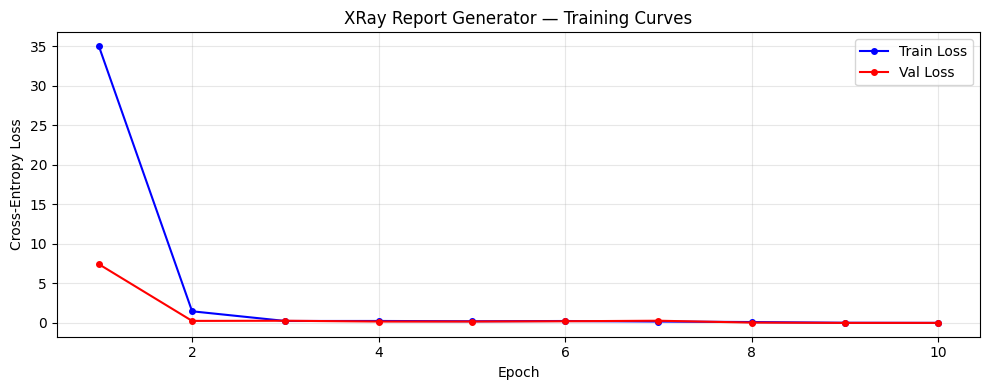

In [ ]:
# ── Loss Curves ─────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(range(1, EPOCHS+1), train_losses, 'b-o', label='Train Loss', markersize=4)
plt.plot(range(1, EPOCHS+1), val_losses,   'r-o', label='Val Loss',   markersize=4)
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('XRay Report Generator — Training Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [ ]:
7# ── Generate a Sample Report ────────────────────────────────
model.eval()

# Take a sample from validation set
sample      = val_dataset[0]
pixel_values = sample['pixel_values'].unsqueeze(0).to(device)  # [1, 3, 224, 224]

# Generate report
generated_ids = model.generate(
    pixel_values,
    bos_id         = BOS_ID,
    eos_id         = EOS_ID,
    max_new_tokens = 80,
    temperature    = 0.7
)

# Decode tokens → text
generated_text = tokenizer.decode(generated_ids, skip_special_tokens=True)
ground_truth   = val_data[0]['report']

print('=' * 60)
print('🔬 GROUND TRUTH REPORT:')
print(ground_truth)
print()
print('🤖 GENERATED REPORT:')
print(generated_text)
print('=' * 60)

🔬 GROUND TRUTH REPORT:
The lungs are clear. No evidence of pneumonia or pleural effusion. Heart size is normal.

🤖 GENERATED REPORT:
 There is increased opacity in the right lower lobe, suggesting possible pneumonia. Heart size normal. 


## 7. What's Next?

This is a **working prototype**. To turn it into a production-ready system:

1. **Replace synthetic data** with the real IU X-Ray dataset (7,470 samples)
2. **Scale up** the decoder (more blocks, larger d_model)
3. **Add BLEU / ROUGE metrics** to evaluate report quality
4. **Fine-tune CLIP** on medical images (unfreeze gradually)
5. **Implement beam search** instead of greedy sampling for better generation

### Architecture inspired by:
- [LLaVA](https://arxiv.org/abs/2304.08485) — MLP projection bridge between vision and language
- [CLIP](https://arxiv.org/abs/2103.00020) — Frozen visual encoder
- [GPT-2](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf) — Autoregressive decoder


In [ ]:
import torch
import gradio as gr
from PIL import Image
import torchvision.transforms as transforms
import torch.nn.functional as F

# ==========================================
# 1. Device Setup & Verification
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# (Note: Assumes 'model', 'tokenizer', 'BOS_ID', and 'EOS_ID'
# are already defined and loaded in your notebook from your training cells).

# ==========================================
# 2. Image Preprocessing Pipeline for X-rays
# ==========================================
# This transform pipeline matches standard CLIP requirements (224x224, 3 channels, normalization)
xray_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ==========================================
# 3. Inference Function for Gradio
# ==========================================
def generate_xray_report(image: Image.Image) -> str:
    """
    Receives an uploaded Chest X-ray image, preprocesses it,
    and uses the built-in XRayReportGenerator.generate() method
    to produce the diagnostic report.
    """
    if image is None:
        return "⚠️ Error: Please upload a valid Chest X-ray image first."

    try:
        # Set model to evaluation mode
        model.eval()

        # Convert PIL image to RGB
        image_rgb = image.convert("RGB")

        # Apply transforms, add batch dimension [1, 3, 224, 224], and move to device
        pixel_values = xray_transform(image_rgb).unsqueeze(0).to(device)

        # Call the built-in generate method defined inside your XRayReportGenerator class
        with torch.no_grad():
            generated_token_ids = model.generate(
                pixel_values   = pixel_values,
                bos_id         = BOS_ID,
                eos_id         = EOS_ID,
                max_new_tokens = 100,
                temperature    = 0.6
            )

        # Decode the generated token ID list back into human-readable text using your tokenizer
        generated_text = tokenizer.decode(generated_token_ids, skip_special_tokens=True)

        return generated_text

    except Exception as e:
        return f"❌ An error occurred during processing or generation: {str(e)}"

# ==========================================
# 4. Gradio Web UI Layout & Launch
# ==========================================
demo = gr.Interface(
    fn=generate_xray_report,
    inputs=gr.Image(type="pil", label="📂 Upload Chest X-ray Image (PNG/JPG)"),
    outputs=gr.Textbox(label="📝 AI-Generated Diagnostic Report", lines=6),

    title="🩺 Chest X-ray Multimodal Report Generator (CLIP + GPT-2)",
    description="""
    This application utilizes your trained custom Vision-Language model to analyze chest X-ray images
    and automatically generate preliminary clinical reports.
    <br>
    <em>Disclaimer: This tool is for research and experimental purposes only and does not replace professional medical advice.</em>
    """,
    theme=gr.themes.Soft()
)

if __name__ == "__main__":
    # Launch the Gradio app (creates a shareable public link)
    demo.launch(share=True, debug=True)

Using device: cuda


/usr/local/lib/python3.12/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://a5471624dbdc2ce1fa.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7861 <> https://a5471624dbdc2ce1fa.gradio.live


In [ ]:
import torch
